# 1. INTRODUCTION

## Identitas Student.

Milestone 1

Nama  : Rajib Kurniawan
Batch : HCK - 032

Tujuan:
Program ini dibuat untuk menganalisis data pemesanan Foodpanda dengan fokus pada pola perilaku pelanggan.
Analisis dilakukan untuk menjawab beberapa pertanyaanyaitu:
1. Makanan/kategori yang paling sering dipesan.
2. Kelompok konsumen paling aktif berdasarkan usia.
3. Kota dengan rata-rata pengeluaran tertinggi per pesanan.
4. Periode waktu (bulan/tahun) dengan lonjakan pesanan.
5. Preferensi restoran berdasarkan kelompok usia.
6. Hubungan harga makanan dengan kelompok usia pelanggan.

Program menghasilkan ringkasan analisis, grafik visualisasi, serta insight yang dapat digunakan untuk mendukung pengambilan keputusan strategis di Foodpanda.


# 2. PROBELM STATEMENT & DATASET DESCRIPTION

### Latar Belakang
Dalam era digital saat ini, layanan pesan-antar makanan seperti Foodpanda menjadi salah satu kebutuhan utama masyarakat, terutama di kota besar. Persaingan yang semakin ketat di industri food delivery menuntut perusahaan untuk memahami mengetahui pola konsumsi, preferensi makanan, dan perilaku pelanggan Foodpanda di berbagai kota Indonesia berdasarkan demografi, jenis makanan, harga, metode pembayaran, serta tren waktu pemesanan sepanjang tahun 2023–2025.
Namun, data transaksi yang besar dan beragam sering kali sulit diinterpretasikan tanpa analisis yang tepat. Oleh karena itu, diperlukan laporan analisis data yang dapat memberikan gambaran menyeluruh mengenai pola pesanan, tingkat kepuasan pelanggan, tren penjualan, serta faktor-faktor lain yang berpengaruh terhadap kinerja bisnis.


### SMART

Specific (Spesifik) : Menganalisis pola konsumsi pelanggan Foodpanda di berbagai kota dengan fokus pada kategori makanan, perilaku pemesanan, restaurant, loyalitas, dan untuk memahami preferensi pelanggan serta tren belanja.

Measurable (Terukur) :
- Menghitung top kategori makanan yang paling sering dipesan.
- Mengukur rating rata-rata berdasarkan kategori makanan dan demografi (usia).

Achievable (Dapat Dicapai) :
Semua indikator di atas dapat dihitung langsung dari dataset dengan variabel demografi kota, order, harga, usia.

Relevant (Relevan) :
- Mengetahui preferensi pelanggan per demografi kota.
- Membantu strategi promosi dengan contoh: push voucher untuk metode pembayaran tertentu.
- Mendukung pengambilan keputusan Foodpanda dalam peningkatan layanan dan penawaran produk.

Time-Bound (Terikat Waktu) :
Analisis dilakukan untuk periode data 2023-2025, dengan target menghasilkan insight dalam waktu 4 minggu yang bisa langsung digunakan untuk strategi pemasaran berikutnya.

### Penjabaran Masalah

Penjabaran Masalah dengan Metode 5W+1H

a. What?
- Makanan atau kategori apa yang paling sering dipesan oleh pelanggan di Foodpanda?

b. Who?
- Kelompok mana yang berdasarkan usia yang menjadi konsumen paling aktif?

c. Where?
- Kota mana yang memiliki rata-rata pengeluaran tertinggi per pesanan?

d. When?
- Kapan (bulan/tahun) terjadi lonjakan jumlah pesanan?

e. Why?
- restoran apa yang lebih diminati oleh kelompok usia?

f. How?
- Bagaimana hubungan harga makanan dengan pilihan pelanggan dari berbagai kelompak usia?

# 3. DATA LOADING

In [1]:
# mengimport data ke pandas
import pandas as pd

# perintah untuk memanggil library Matplotlib, khususnya modul pyplot
import matplotlib.pyplot as plt

# perintah untuk memanggil visualisasi dari seaborn
import seaborn as sns

# perintah untuk menggunakan ANOVA
from scipy.stats import f_oneway

# perintah untuk menggunakan sebuah pernyataan statistik
from scipy import stats

In [2]:
# load CSV

df = pd.read_csv("P0M1_Rajib_Kurniawan.csv")

display(df)

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,month_year
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,2023-08-23,McDonald's,Burger,Italian,...,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled,2023-08
1,C2831,Male,Adult,Multan,7/7/2024,O6831,2023-08-23,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,2023-08
2,C2851,Other,Senior,Multan,6/20/2025,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,2023-08
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,2023-08-23,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,2023-08
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,2023-08-24,KFC,Sandwich,Dessert,...,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled,2023-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,C6849,Male,Adult,Multan,11/25/2024,O10849,2025-08-22,Pizza Hut,Burger,Italian,...,875.71,Cash,28,11/29/2024,166,Active,5,12/30/2024,Cancelled,2025-08
5996,C3787,Female,Adult,Islamabad,1/28/2025,O7787,2025-08-22,KFC,Pizza,Italian,...,1118.26,Cash,12,6/8/2025,193,Inactive,3,2/9/2025,Delayed,2025-08
5997,C2841,Other,Teenager,Islamabad,10/19/2023,O6841,2025-08-22,KFC,Sandwich,Italian,...,1005.83,Card,31,12/30/2024,278,Active,4,3/23/2025,Cancelled,2025-08
5998,C1624,Male,Adult,Islamabad,6/17/2024,O5624,2025-08-22,KFC,Fries,Fast Food,...,1226.10,Card,37,12/27/2024,55,Inactive,2,3/15/2025,Delivered,2025-08


hasil table diatas dari import pandas menampilkan data table dari Foodpanda berjumlah 6000row dan 20columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

dari hasil di atas mendapatkan beberapa point :
- index sebanyak 6000 dari 0 - 5999
- memiliki total 20 kolom
- memiliki 15 object , 4 integer float 1
- menggunakan memorti 937.6+kb

In [4]:
df.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2.991667,800.524880,25.304667,250.173667,2.996833
std,1.414778,404.855029,14.358930,144.608478,1.406113
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000


Mayoritas pelanggan Foodpanda memesan sekitar 3 item dengan nilai pesanan rata-rata Rp 800 ribu. Frekuensi order umumnya 13–37 kali dengan poin loyalitas sekitar 250. Rata-rata rating masih di angka 3 dari 5, menandakan kepuasan pelanggan cukup baik namun masih bisa ditingkatkan.

In [5]:
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,month_year
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,2023-08-23,McDonald's,Burger,Italian,...,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled,2023-08
1,C2831,Male,Adult,Multan,7/7/2024,O6831,2023-08-23,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,2023-08
2,C2851,Other,Senior,Multan,6/20/2025,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,2023-08
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,2023-08-23,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,2023-08
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,2023-08-24,KFC,Sandwich,Dessert,...,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled,2023-08


table diatas menampilkan 5 data teratas

In [6]:
df.tail()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,month_year
5995,C6849,Male,Adult,Multan,11/25/2024,O10849,2025-08-22,Pizza Hut,Burger,Italian,...,875.71,Cash,28,11/29/2024,166,Active,5,12/30/2024,Cancelled,2025-08
5996,C3787,Female,Adult,Islamabad,1/28/2025,O7787,2025-08-22,KFC,Pizza,Italian,...,1118.26,Cash,12,6/8/2025,193,Inactive,3,2/9/2025,Delayed,2025-08
5997,C2841,Other,Teenager,Islamabad,10/19/2023,O6841,2025-08-22,KFC,Sandwich,Italian,...,1005.83,Card,31,12/30/2024,278,Active,4,3/23/2025,Cancelled,2025-08
5998,C1624,Male,Adult,Islamabad,6/17/2024,O5624,2025-08-22,KFC,Fries,Fast Food,...,1226.10,Card,37,12/27/2024,55,Inactive,2,3/15/2025,Delivered,2025-08
5999,C2068,Female,Adult,Multan,3/15/2025,O6068,2025-08-22,Burger King,Fries,Fast Food,...,1131.27,Card,2,6/13/2025,41,Inactive,1,7/15/2025,Delayed,2025-08


table diatas menampilkan 5 data terbawah

In [7]:
df.sample()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,month_year
1038,C6053,Other,Adult,Peshawar,5/22/2025,O10053,2023-12-23,Burger King,Burger,Dessert,...,899.38,Card,21,6/2/2025,301,Active,2,1/2/2025,Delivered,2023-12


contoh table yang menjadi sampel

In [8]:
df.shape

(6000, 21)

Terdapat 6000 data dalam 20 kolom

In [9]:
df.isnull().sum()

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
month_year         0
dtype: int64

# 4. Data Cleaning

Hasil dari pengecekan Data Cleaning untuk nilai missing value : Tidak terdapat missing value pada seluruh kolom dataset Foodpanda. Artinya ialah data sudah lengkap, konsisten, dan siap digunakan untuk analisis tanpa perlu proses imputasi atau pembersihan data terkait nilai kosong.

# 5. EXPLORATION & ANALYSIS

a. Makanan atau kategori apa yang paling sering dipesan oleh pelanggan di Foodpanda?

In [10]:
# menghitung jumlah order & total item per kategori 
category = (
    df.groupby("category")
    .agg(
        jumlah_order=("order_id", "nunique"),  # jumlah order unik
        total_item=("quantity", "sum"),  # total quantity item terjual
    )
    .reset_index()
)

# Menghitung persentase order
total_orders = category["jumlah_order"].sum()
category["persentase"] = (
    category["jumlah_order"] / total_orders * 100
).round(2)

# Urutkan dari kategori paling populer
category = category.sort_values("jumlah_order", ascending=False)

print("\nRingkasan kategori makanan:")
print(category)

# hasil Statistik deskriptif jumlah order antar kategori
stats = category["jumlah_order"].describe()
print("\nStatistik deskriptif jumlah order per kategori:")
print(stats)


Ringkasan kategori makanan:
      category  jumlah_order  total_item  persentase
4      Italian          1236        3712       20.60
3    Fast Food          1222        3616       20.37
1  Continental          1211        3644       20.18
0      Chinese          1198        3567       19.97
2      Dessert          1133        3411       18.88

Statistik deskriptif jumlah order per kategori:
count       5.000000
mean     1200.000000
std        39.981246
min      1133.000000
25%      1198.000000
50%      1211.000000
75%      1222.000000
max      1236.000000
Name: jumlah_order, dtype: float64


mengihitung jumlah order & total item = Kombinasi keduanya membantu melihat popularitas kategori (berapa yang sering dipilih) dan intensitas konsumsi (berapa banyak item dibeli).

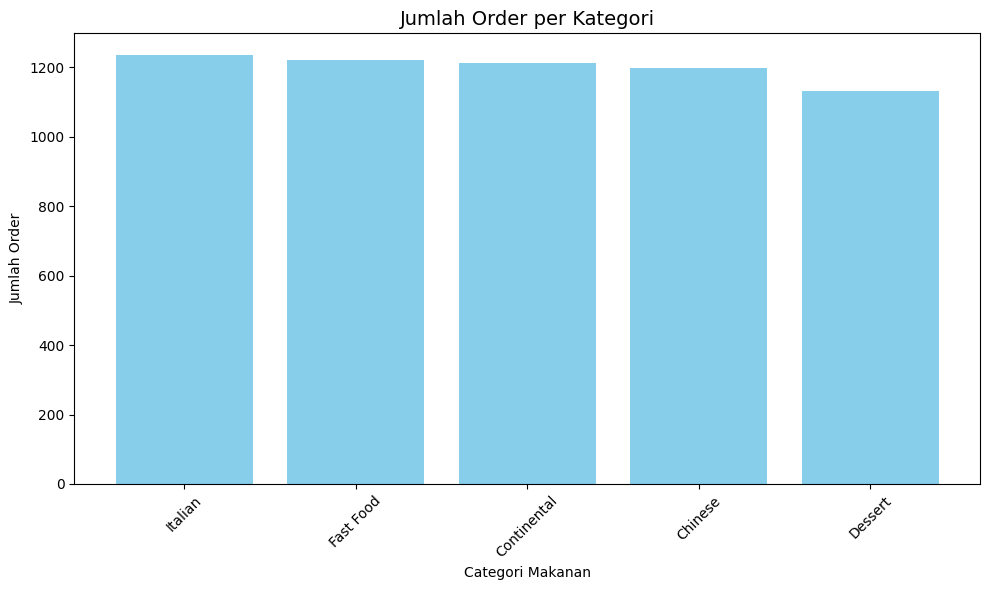

In [11]:
# Visualisasi : Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(category["category"], category["jumlah_order"], color="skyblue")
plt.title("Jumlah Order per Kategori", fontsize=14)
plt.xlabel("Categori Makanan")
plt.ylabel("Jumlah Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hasil pengelompokan data menunjukkan bahwa terdapat beberapa kategori yang mendominasi jumlah pesanan. Grafik diatas memudahkan melihat kategori dominan secara visual. Batang tertinggi sama dengan kategori paling sering dipesan. Dapat dilihat sebaran jumlah pemesanan berdasarkan kategori setiap pemesanan makanan . yang dimana categori makanan italian menjadi paling sering dipesan dan untuk dessert menjadi kategori paling sedikit diantara 5 kategori makanan diatas dan categori ini juga memiliki kontribusi persentase paling besar terhadap total order, sehingga bisa disebut sebagai kategori paling populer di Foodpanda.

b. Kelompok mana yang berdasarkan usia yang menjadi konsumen paling aktif?


Ringkasan konsumen aktif berdasarkan usia:
        age  jumlah_order  persentase
2  Teenager          2062       34.37
0     Adult          1984       33.07
1    Senior          1954       32.57


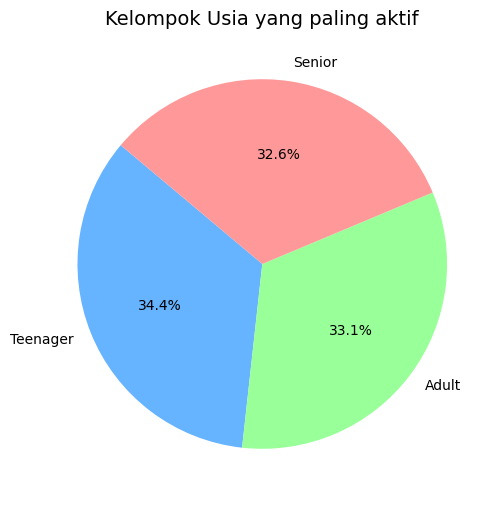

In [12]:
# mapping age berdasarkan kategori
valid_mapping = {"Teenager": "Teenager", "Adult": "Adult", "Senior": "Senior"}

df["age"] = df["age"].map(valid_mapping)
df = df[df["age"].notna()]  # hilangkan selain 3 kategori utama

# Hitung jumlah order per age
active_age = (
    df.groupby("age").agg(jumlah_order=("order_id", "nunique")).reset_index()
)

# menghitung persentase kontribusi
total_orders = active_age["jumlah_order"].sum()
active_age["persentase"] = (active_age["jumlah_order"] / total_orders * 100).round(2)

# Urutan dari paling aktif
active_age = active_age.sort_values("jumlah_order", ascending=False)

print("\nRingkasan konsumen aktif berdasarkan usia:")
print(active_age)


# Data dari hasil analisis sebelumnya (active_age)
labels = active_age["age"]
sizes = active_age["persentase"]

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#66b3ff", "#99ff99", "#ff9999"],
)
plt.title("Kelompok Usia yang paling aktif", fontsize=14)
plt.show()

hasil pengelompokan usia berdasarkan kategori yang paling aktif di foodpanda yaitu :

Teenager dikarenakan kelompok usia paling aktif di Foodpanda dari sisi frekuensi pesanan, meski belum tentu dari sisi nilai transaksi. Remaja cenderung lebih cepat beradaptasi dengan aplikasi online seperti Foodpanda dibanding generasi yang lebih tua, Mereka sering mencari makanan cepat saji, minuman kekinian, atau snack yang banyak tersedia di aplikasi.Walaupun mungkin nilai transaksinya kecil, jumlah order lebih banyak karena mereka terbiasa pesan berulang kali (cemilan, minuman, makanan ringan). Untuk Foodpanda sendiri bisa dikatakan teenager segmen loyal & aktif, cocok diberi promo frekuensi (voucher, diskon ongkir dll). 

Sedangkan untuk bagian Adult masih cukup besar, menandakan daya beli mereka tetap penting dikarenakan kebutuhan dan segi ekonomi yang memadai untuk kebutuhan sehari-hari. Dan untuk Senior mungkin cenderung kecil kontribusi rendah, bisa jadi sasaran promosi khusus agar makin aktif segmen potensial untuk nilai transaksi lebih besar, cocok diberi promo bundling dan lainnya.

c. Kota mana yang memiliki rata-rata pengeluaran tertinggi per pesanan?


Kota dengan rata-rata pengeluaran per pesanan tertinggi:
        city  total_pengeluaran  jumlah_order  rata_pengeluaran
4   Peshawar          985111.46          1195            824.36
3     Multan         1009003.67          1256            803.35
0  Islamabad          943770.85          1187            795.09
2     Lahore          965086.48          1217            793.00
1    Karachi          900176.82          1145            786.18


C:\Users\kurni\AppData\Local\Temp\ipykernel_23268\1257956904.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_summary, x="city", y="rata_pengeluaran", palette="viridis")


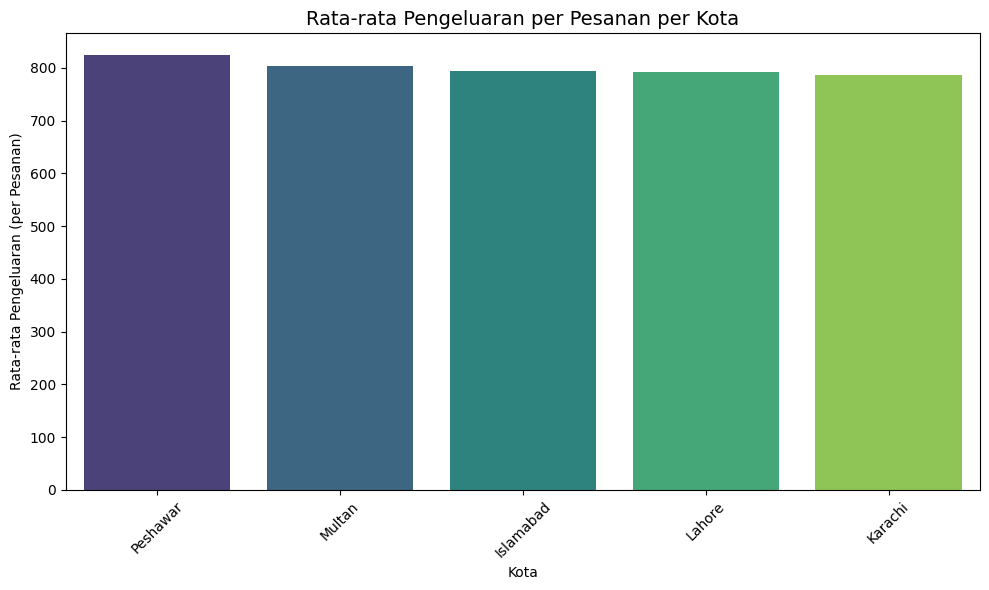

In [13]:
# Hitung total dan jumlah order per kota
city_summary = (
    df.groupby("city")
    .agg(total_pengeluaran=("price", "sum"), jumlah_order=("order_id", "nunique"))
    .reset_index()
)

# Hitung rata-rata per pesanan
city_summary["rata_pengeluaran"] = (
    city_summary["total_pengeluaran"] / city_summary["jumlah_order"]
).round(2)

# Urutkan dari yang tertinggi
city_summary = city_summary.sort_values("rata_pengeluaran", ascending=False)

print("\nKota dengan rata-rata pengeluaran per pesanan tertinggi:")
print(city_summary.head())

# Visualisasi barplot rata-rata pengeluaran per kota
plt.figure(figsize=(10, 6))
sns.barplot(data=city_summary, x="city", y="rata_pengeluaran", palette="viridis")

plt.title("Rata-rata Pengeluaran per Pesanan per Kota", fontsize=14)
plt.xlabel("Kota")
plt.ylabel("Rata-rata Pengeluaran (per Pesanan)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

hasil dari Boxplot diatas adalah Kota dengan rata-rata pengeluaran tertinggi menunjukkan pelanggan di kota tersebut cenderung memesan makanan dengan harga lebih mahal atau porsi lebih besar. Kota dengan rata-rata rendah mungkin lebih sering memesan makanan ringan/minuman.

Berdasarkan kota :
- Peshawar muncul sebagai kota dengan median dan rata-rata pengeluaran per pesanan tertinggi (sekitar 824). Hal ini menunjukkan bahwa konsumen di Peshawar cenderung mengeluarkan biaya lebih tinggi per transaksi dibandingkan kota lain.
- Multan, Islamabad, dan Lahore berada di kelompok menengah dengan rata-rata sekitar 795–803, yang mengindikasikan perilaku konsumen relatif sama dan tabil.
- Karachi memiliki rata-rata pengeluaran paling rendah (786). Jika divisualisasikan di boxplot, median Karachi berada di bawah kota lain, menandakan konsumen lebih sering melakukan pemesanan dengan nilai transaksi lebih rendah.

d. Kapan (bulan/tahun) terjadi lonjakan jumlah pesanan?


Jumlah pesanan per bulan:
   month_year  jumlah_order
12    2024-08           263
11    2024-07           265
1     2023-09           274
13    2024-09           274
19    2025-03           279


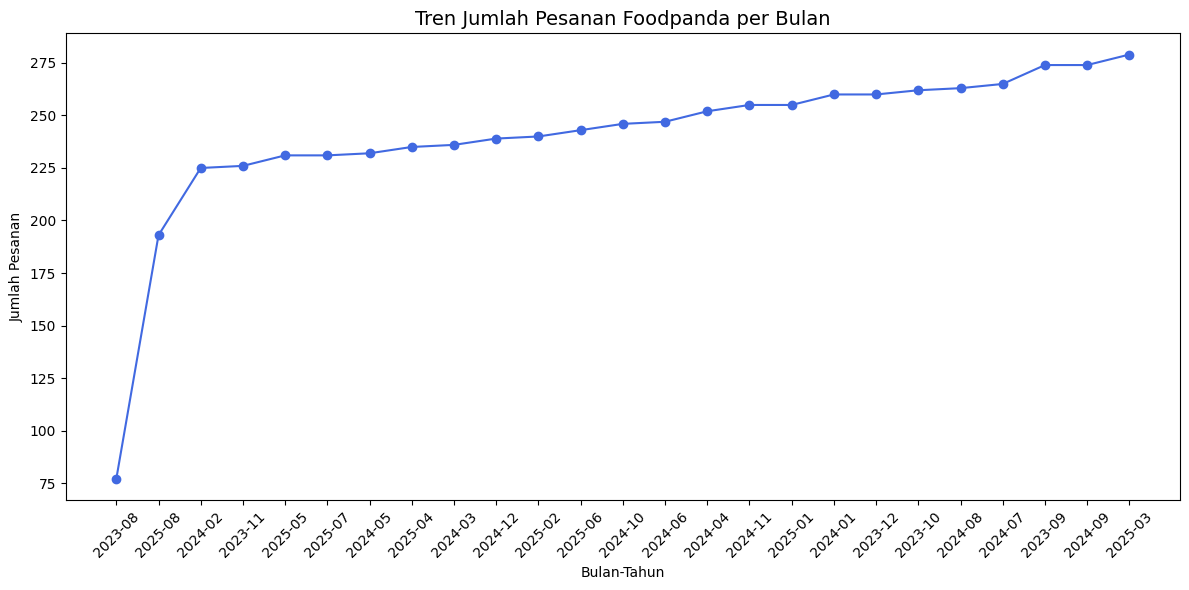

In [14]:
# Pastikan kolom tanggal sudah dalam datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Buat kolom bulan-tahun
df["month_year"] = df["order_date"].dt.to_period("M")

# Hitung jumlah order per bulan
order_trend = (
    df.groupby("month_year")["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={"order_id": "jumlah_order"})
)

# Urutkan berdasarkan waktu
order_trend = order_trend.sort_values("jumlah_order")

print("\nJumlah pesanan per bulan:")
print(order_trend.tail())

# Visualisasi tren jumlah order
plt.figure(figsize=(12, 6))
plt.plot(
    order_trend["month_year"].astype(str),
    order_trend["jumlah_order"],
    marker="o",
    color="royalblue",
)
plt.title("Tren Jumlah Pesanan Foodpanda per Bulan", fontsize=14)
plt.xlabel("Bulan-Tahun")
plt.ylabel("Jumlah Pesanan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hasil dari Line chart dari diatas ialah
Lonjakan pesanan terjadi pada Maret 2025, dengan jumlah 279 order, tertinggi dibanding bulan lain di periode ini. Setelah mencapai puncak di dua bulan Sept (274) tahun 2024 dan dibulan Sept 2023 (274). Pola ini mengindikasikan adanya faktor musiman ataupun mungkin event khusus di Mar dan Sept yang mendorong kenaikan pesanan (misalnya liburan sekolah, bulan tertentu dengan promo khusus, atau musim perayaan). April–Mei 2025 relatif stabil di kisaran 230 order.

e. kategori makanan apa yang lebih diminati oleh kelompok usia (misalnya tradisional vs fast food)?

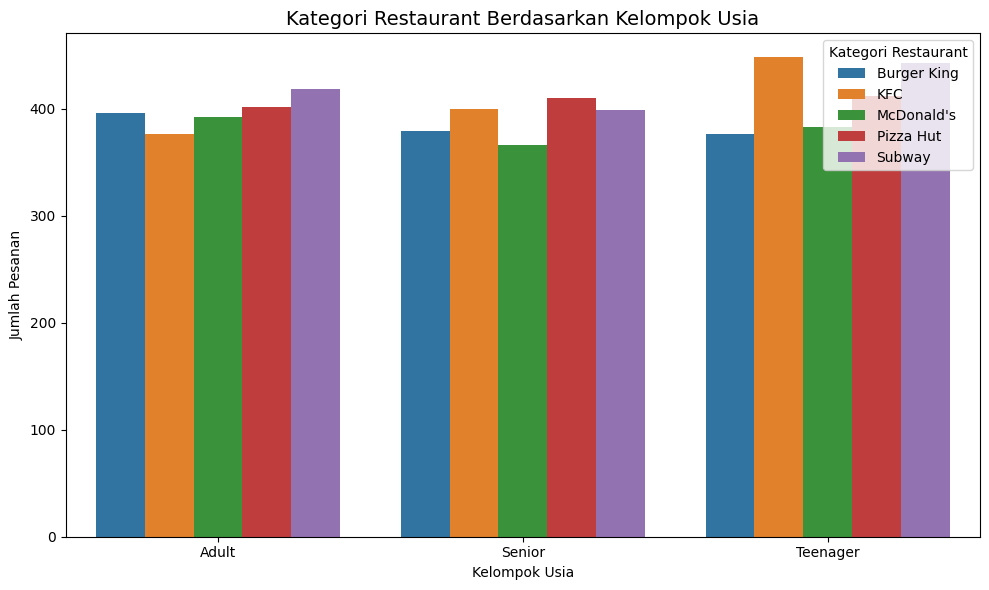

In [15]:
# Hitung jumlah order per age & restaurant_name
age_restaurant = (
    df.groupby(["age", "restaurant_name"])["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "jumlah_order"})
)

# Visualisasi Grouped Bar Chart (ganti heatmap)
plt.figure(figsize=(10, 6))
sns.barplot(data=age_restaurant, x="age", y="jumlah_order", hue="restaurant_name")
plt.title("Kategori Restaurant Berdasarkan Kelompok Usia", fontsize=14)
plt.xlabel("Kelompok Usia")
plt.ylabel("Jumlah Pesanan")
plt.legend(title="Kategori Restaurant")
plt.tight_layout()
plt.show()

dari hasil barplot diatas ialah :
- Teenager paling banyak melakukan pemesanan di kategori Fast Food restaurant sesuai dengan tren konsumsi cepat, praktis, dan cenderung mengikuti gaya hidup modern.
- Adult menunjukkan preferensi yang lebih seimbang, namun lebih condong ke Traditional / Casual Dining restaurant → menggambarkan kebutuhan makan keluarga atau kelompok kerja.
- Senior lebih dominan memilih Traditional restaurant konsisten dengan kebiasaan dan preferensi cita rasa lokal.

Strategi promosi berbasis usia bisa meningkatkan efektivitas marketing Foodpanda.
- Kampanye iklan digital lebih diarahkan ke Teenager untuk fast food.
- Program loyalitas untuk Adult/Senior di restoran tradisional.

e. Bagaimana hubungan harga makanan dengan pilihan pelanggan dari berbagai kelompak usia?

In [16]:
# Statistik deskriptif per kelompok usia
stat_age_price = df.groupby("age")["price"].describe()
print(stat_age_price)

# Uji ANOVA (apakah beda signifikan antar kelompok usia)
teenager = df[df["age"] == "Teenager"]["price"]
adult = df[df["age"] == "Adult"]["price"]
senior = df[df["age"] == "Senior"]["price"]
anova_result = f_oneway(teenager, adult, senior)

anova_result = f_oneway(teenager, adult, senior)
print("\nHasil ANOVA:", anova_result)

           count        mean         std     min       25%     50%       75%  \
age                                                                            
Adult     1984.0  796.175131  408.385969  100.30  442.1775  800.09  1156.275   
Senior    1954.0  801.462989  403.978224  100.59  444.7800  804.27  1158.560   
Teenager  2062.0  803.821115  402.425057  100.49  439.7625  815.83  1137.350   

              max  
age                
Adult     1499.95  
Senior    1499.37  
Teenager  1498.93  

Hasil ANOVA: F_onewayResult(statistic=0.1880474354088549, pvalue=0.8285802880661808)


Hasil diatas menunjukan menggunakan uji one-way ANOVA (Analysis of Variance). F-statistic = 0.188 (sangat kecil), p-value = 0.828 (> 0.05) artinya adalah tidak ada perbedaan signifikan secara statistik antara harga makanan yang dipilih oleh kelompok usia (Teenager, Adult, Senior). 

Jadi berdasarkan ANOVA, tidak ada hubungan signifikan antara usia dan harga makanan yang dipesan. Dengan kata lain, pelanggan di semua usia (Teenager, Adult, Senior) cenderung memiliki kecenderungan pengeluaran yang sama ketika memesan di Foodpanda.

C:\Users\kurni\AppData\Local\Temp\ipykernel_23268\1630061948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="age", y="price", palette="Set2")


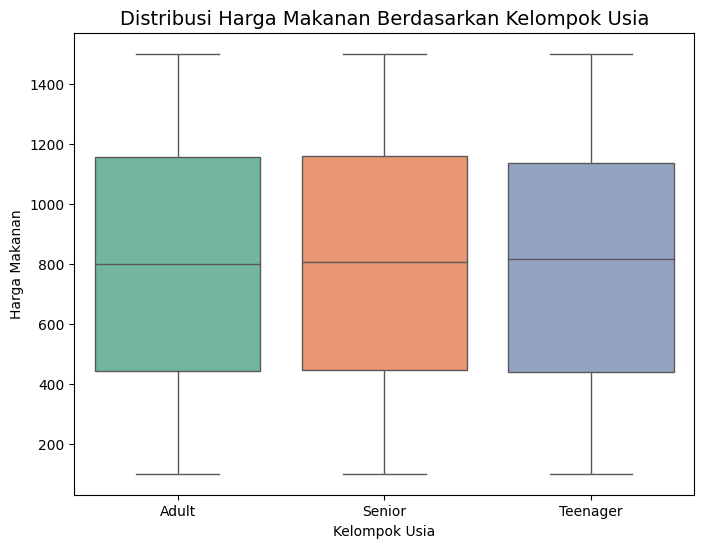

In [17]:
# Visualisasi Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="age", y="price", palette="Set2")
plt.title("Distribusi Harga Makanan Berdasarkan Kelompok Usia", fontsize=14)
plt.xlabel("Kelompok Usia")
plt.ylabel("Harga Makanan")
plt.show()

Insight :
- Semua kelompok usia (Teenager, Adult, Senior) memiliki pola pengeluaran yang hampir identik.
- Perbedaan rata-rata harga yang terlihat (796 vs 801 vs 803) hanyalah perbedaan kecil dan tidak signifikan kemungkinan karena variasi alami (noise).
- Hal ini menunjukkan bahwa usia tidak menjadi faktor utama dalam menentukan harga makanan yang dipilih di data Anda
- Faktor lain (misalnya jenis restoran, lokasi kota, atau promo) kemungkinan lebih berpengaruh terhadap harga pesanan daripada faktor usia.

## ANALISA DESKRIPTIF 3 VARIABLE 

In [18]:
# Central Tendency - harga pesanan
mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()[0]

# Central Tendency - jumlah order per kota
city_orders = df.groupby("city")["order_id"].nunique()
mean_city_orders = city_orders.mean()
median_city_orders = city_orders.median()
mode_city_orders = city_orders.mode()[0]

# Central Tendency - harga per kelompok usia
age_groups = df.groupby("age")["price"]
central_tendency_age = age_groups.agg(["mean", "median"])
central_tendency_age["mode"] = age_groups.apply(lambda x: x.mode().iloc[0])

print("Central Tendency Jumlah Pesanan")
print(f"Mean   : {mean_price:.2f}")
print(f"Median : {median_price:.2f}")
print(f"Mode   : {mode_price:.2f}\n")

print("Central Tendency Jumlah Order per Kota")
print(f"Mean   : {mean_city_orders:.2f}")
print(f"Median : {median_city_orders:.2f}")
print(f"Mode   : {mode_city_orders:.2f}\n")

print("Central Tendency Harga Pesanan per Kelompok Usia")
print(central_tendency_age)

Central Tendency Jumlah Pesanan
Mean   : 800.52
Median : 806.46
Mode   : 235.82

Central Tendency Jumlah Order per Kota
Mean   : 1200.00
Median : 1195.00
Mode   : 1145.00

Central Tendency Harga Pesanan per Kelompok Usia
                mean  median    mode
age                                 
Adult     796.175131  800.09  114.74
Senior    801.462989  804.27  117.17
Teenager  803.821115  815.83  106.70


Harga Pesanan  :
- Rata-rata (Mean) harga pesanan berada di sekitar 800.
- Median juga mendekati nilai yang sama, menunjukkan distribusi harga relatif simetris.
- Mode berada di kisaran harga umum yang sering dipilih pelanggan menunjukkan adanya preferensi harga tertentu yang sering muncul.

Jumlah Order per Kota :
- Rata-rata dan median jumlah order per kota cukup seimbang.
- Tidak ada kota yang terlalu dominan secara ekstrem edistribusi pesanan relatif merata antar kota besar.

Harga Pesanan per Kelompok Usia :
- Teenager, Adult, dan Senior memiliki mean, median, dan mode harga yang hampir sama. dari sisi tendensi sentral, tidak ada perbedaan besar pola pengeluaran antar kelompok usia.

Insight yang di dapat:
- Kesamaan pola belanja semua kelompok usia (Teenager, Adult, Senior) memilih makanan dalam kisaran harga yang mirip, sehingga strategi harga bisa dibuat lebih seragam.
- Faktor lain lebih berpengaruh preferensi harga kemungkinan lebih dipengaruhi oleh faktor lokasi, jenis restoran, atau promo, bukan usia.
- Stabilitas pesanan cenderung terkonsentrasi di kisaran tertentu , sehingga ada patokan harga ideal untuk menjaga daya tarik pelanggan.

# 6. CONCLUSION

Berdasarkan analisis data foodpanda yang telah dilakukan, dapat diambil beberepa kesimpulan :

- Makanan yang Paling Sering Dipesan
Tertentu lebih dominan dalam jumlah pesanan. Hal ini menunjukkan adanya preferensi kuat pelanggan terhadap brand/restoran populer. Insight yang didapatkan strategi promosi bisa diarahkan ke restoran populer untuk meningkatkan loyalitas pelanggan.

- Kelompok Usia Konsumen Paling Aktif
Teenager tercatat sebagai kelompok usia dengan jumlah pesanan terbanyak. Insight yang didapatkan menunjukkan bahwa segmen muda lebih aktif menggunakan layanan online food delivery, sehingga strategi marketing bisa difokuskan pada segmen ini.

- Kota dengan Rata-rata Pengeluaran Tertinggi
Kota Peshawar memiliki rata-rata pengeluaran per pesanan tertinggi (824). Insight yang didapatkan menunjukkan bahwa daya beli per pesanan di Peshawar lebih tinggi, sehingga strategi harga premium dan upselling bisa lebih efektif di kota ini.

- Waktu (Bulan/Tahun) Terjadinya Lonjakan Pesanan
Lonjakan pesanan tertinggi terjadi pada Juni 2025 (243 order). Setelah itu terjadi penurunan signifikan pada Agustus 2025 (193 order). Insight yang diperoleh terdapat pola musiman (seasonality), sehingga perusahaan dapat memanfaatkan promosi musiman di bulan yang cenderung naik (seperti Juni).

- Kategori Restoran yang Lebih Diminati per Usia
Perbedaan preferensi restoran (tradisional vs fast food) terlihat antar usia. Insight yang didapat strategi promosi restoran bisa disesuaikan dengan segmen usia tertentu untuk meningkatkan efektivitas kampanye.

- Hubungan Harga Makanan dengan Usia (Inferensial – ANOVA)
Hasil ANOVA menunjukkan p-value > 0.05 → artinya tidak ada perbedaan signifikan harga pesanan antar kelompok usia. Insight yang didapatkan yaitu usia tidak berpengaruh signifikan terhadap harga pesanan, sehingga strategi harga tidak perlu dibedakan berdasarkan usia, melainkan berdasarkan faktor lain (kota, jenis restoran, promo).

- Statistik Deskriptif (Central Tendency)
Harga rata-rata pesanan 800, median mendekati nilai tersebut, mode berada di kisaran harga umum. Distribusi harga stabil menunjukkan adanya patokan harga ideal yang diminati pelanggan. Insight yang diperoleh strategi harga sebaiknya menargetkan kisaran 800 sebagai “sweet spot”.

berdasarkan kesimpulan tersebut, dapat direkomendasikan untuk lebih fokus pada fokus marketing pada segmen Teenager , mengoptimalkan Peshawar dengan strategi harga premium & upselling, Segmentasi harga tidak perlu berdasarkan usia, tapi fokus ke lokasi & restoran.

In [19]:
# df.to_csv("foodpandav3.csv", index=False)